## Descrição para a Etapa de Analytics
Com os dados de títulos, anos de lançamento, gêneros e classificações etárias das séries do Globoplay devidamente coletados, estamos prontos para entrar na fase de analytics. Essa etapa é crucial para extrair insights valiosos e compreender melhor os padrões presentes nos dados.

### A Importância da Análise
 - Identificação de Tendências:

Quais gêneros têm sido mais populares ao longo dos anos?
Existe uma predominância de séries para determinada faixa etária?
 - Exploração Temporal:

Como o número de lançamentos evoluiu ao longo do tempo?
Algum período específico se destaca por um aumento ou redução na produção de séries?
 - Segmentação de Público:

Quais gêneros estão mais associados a faixas etárias específicas?
Existe uma relação entre o ano de lançamento e o tipo de público-alvo?
 - Suporte à Tomada de Decisão:

Para plataformas como Globoplay, entender essas informações pode orientar decisões sobre quais tipos de séries adquirir ou produzir, melhorando a oferta para o público.
### Próximos Passos
Na próxima etapa, realizaremos:

- Limpeza e preparação dos dados: Garantindo que estejam prontos para análise.

- Visualização dos dados: Criando gráficos e tabelas que destaquem os padrões mais relevantes.

- Insights detalhados: Respondendo perguntas específicas sobre o comportamento das séries em relação ao tempo, público e gênero.

Essa análise nos permitirá não apenas entender melhor o catálogo atual do Globoplay, mas também identificar oportunidades estratégicas para melhorar a experiência dos usuários e fortalecer o catálogo da plataforma

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('dados_titulos.csv')
df1 = pd.read_csv('dados_anos.csv')
df2 = pd.read_csv('dados_classificacoes_etarias.csv')
df3 = pd.read_csv('dados_genero.csv')

In [3]:
# Conferindo todos os df's
df.head(3)

,0
0,Tapas & Beijos
1,O Mundo Dos Casados
2,Arcanjo Renegado


In [4]:
df.shape

(305, 1)

In [5]:
df1.head(3)

,link,ano_lancamento
0,https://globoplay.globo.com/agora-na-tv/,Ano não encontrado
1,https://globoplay.globo.com/categorias/novelas/,Ano não encontrado
2,https://globoplay.globo.com/categorias/series/,Ano não encontrado


In [6]:
df2.head(3)

,link,classificacao_etaria
0,https://globoplay.globo.com/agora-na-tv/,Não encontrada
1,https://globoplay.globo.com/categorias/novelas/,12
2,https://globoplay.globo.com/categorias/series/,Não encontrada


In [7]:
df3.head(4)

,link,generos
0,https://globoplay.globo.com/agora-na-tv/,[]
1,https://globoplay.globo.com/categorias/novelas/,[]
2,https://globoplay.globo.com/categorias/series/,[]
3,https://globoplay.globo.com/categorias/bbb-25/,[]


In [8]:
# Realizando o merge dos três dataframes
df_merged = df1.merge(df2, on='link').merge(df3, on='link')

# Exibindo o resultado
print(df_merged)

                                                  link      ano_lancamento  \
0             https://globoplay.globo.com/agora-na-tv/  Ano não encontrado   
1      https://globoplay.globo.com/categorias/novelas/  Ano não encontrado   
2       https://globoplay.globo.com/categorias/series/  Ano não encontrado   
3       https://globoplay.globo.com/categorias/bbb-25/  Ano não encontrado   
4     https://globoplay.globo.com/categorias/esportes/  Ano não encontrado   
..                                                 ...                 ...   
311  https://globoplay.globo.com/ferias-em-familia/...                2019   
312  https://globoplay.globo.com/lama-dos-dias/t/ym...                2018   
313  https://globoplay.globo.com/a-generala/t/cM229...                2020   
314  https://globoplay.globo.com/segredos-de-justic...                2016   
315  https://globoplay.globo.com/juntos-a-magia-aco...                2019   

             classificacao_etaria        generos  
0           

In [9]:
type(df_merged)

pandas.core.frame.DataFrame

In [10]:
df_merged.head(10)

,link,ano_lancamento,classificacao_etaria,generos
0,https://globoplay.globo.com/agora-na-tv/,Ano não encontrado,Não encontrada,[]
1,https://globoplay.globo.com/categorias/novelas/,Ano não encontrado,12,[]
2,https://globoplay.globo.com/categorias/series/,Ano não encontrado,Não encontrada,[]
3,https://globoplay.globo.com/categorias/bbb-25/,Ano não encontrado,Não encontrada,[]
4,https://globoplay.globo.com/categorias/esportes/,Ano não encontrado,Não encontrada,[]
5,https://globoplay.globo.com/catalogo/,Ano não encontrado,14,[]
6,https://globoplay.globo.com/busca/,Ano não encontrado,Não encontrada,[]
7,https://globoplay.globo.com/tapas-beijos/t/Vc7...,2011,12,['Comédia']
8,https://globoplay.globo.com/o-mundo-dos-casado...,2020,Autoclassificação etária: 16,['Drama']
9,https://globoplay.globo.com/lalola-entre-dois-...,2024,Autoclassificação etária: 14,['Comédia']


In [11]:
df_merged.tail()

,link,ano_lancamento,classificacao_etaria,generos
311,https://globoplay.globo.com/ferias-em-familia/...,2019,10,['Comédia']
312,https://globoplay.globo.com/lama-dos-dias/t/ym...,2018,Autoclassificação etária: 16,['Drama']
313,https://globoplay.globo.com/a-generala/t/cM229...,2020,Autoclassificação etária: 14,['Drama']
314,https://globoplay.globo.com/segredos-de-justic...,2016,Autoclassificação etária: 14,['Biografia']
315,https://globoplay.globo.com/juntos-a-magia-aco...,2019,Não encontrada,['Drama']


In [12]:
df_merged.isna().sum()

link                    0
ano_lancamento          0
classificacao_etaria    0
generos                 0
dtype: int64

In [13]:
df_merged.nunique()

link                    308
ano_lancamento           39
classificacao_etaria     14
generos                  15
dtype: int64

In [14]:
df_merged.generos.unique()

array(['[]', "['Comédia']", "['Drama']", "['Ação']", "['Mistério']",
       "['Sobrenatural']", "['Suspense']", "['Fantasia']", "['Aventura']",
       "['Infantil']", "['Biografia']", "['Policial']", "['Romance']",
       "['Personalidade']", "['Terror']"], dtype=object)

In [15]:
linhas_erro = df_merged[df_merged['classificacao_etaria'].isin(['Erro', 'Não encontrada'])]

# Exibindo o resultado
print(linhas_erro)

                                                  link      ano_lancamento  \
0             https://globoplay.globo.com/agora-na-tv/  Ano não encontrado   
2       https://globoplay.globo.com/categorias/series/  Ano não encontrado   
3       https://globoplay.globo.com/categorias/bbb-25/  Ano não encontrado   
4     https://globoplay.globo.com/categorias/esportes/  Ano não encontrado   
6                   https://globoplay.globo.com/busca/  Ano não encontrado   
97   https://globoplay.globo.com/rbd-la-familia/t/5...                2007   
315  https://globoplay.globo.com/juntos-a-magia-aco...                2019   

    classificacao_etaria      generos  
0         Não encontrada           []  
2         Não encontrada           []  
3         Não encontrada           []  
4         Não encontrada           []  
6         Não encontrada           []  
97                  Erro  ['Comédia']  
315       Não encontrada    ['Drama']  


Como raspamos todas as séries que há no Globoplay, foi notado que alguns links não teve sua classificação encontrada, mas ao entrar em seu respectivo link, é notado que de fato não há classificação lá e consequentemente permanecerá assim.

In [16]:
linhas_erro_ano = df_merged[df_merged['ano_lancamento'].isin(['Ano não encontrado'])]

# Exibindo o resultado
print(linhas_erro_ano)

                                                  link      ano_lancamento  \
0             https://globoplay.globo.com/agora-na-tv/  Ano não encontrado   
1      https://globoplay.globo.com/categorias/novelas/  Ano não encontrado   
2       https://globoplay.globo.com/categorias/series/  Ano não encontrado   
3       https://globoplay.globo.com/categorias/bbb-25/  Ano não encontrado   
4     https://globoplay.globo.com/categorias/esportes/  Ano não encontrado   
5                https://globoplay.globo.com/catalogo/  Ano não encontrado   
6                   https://globoplay.globo.com/busca/  Ano não encontrado   
44   https://globoplay.globo.com/a-diarista/t/PbTJ6...  Ano não encontrado   
51   https://globoplay.globo.com/sai-de-baixo/t/mC1...  Ano não encontrado   
81   https://globoplay.globo.com/o-album-da-grande-...  Ano não encontrado   
82   https://globoplay.globo.com/o-album-da-grande-...  Ano não encontrado   
155  https://globoplay.globo.com/mister-brau/t/wqf2...  Ano não 

Da mesma forma que alguns links não tem a classificação, há links que não possuem seu ano de lançamento e há também links que não possuí algum tipo de gênero.

In [17]:
# Remover as aspas e os colchetes da coluna 'generos'
df_merged['generos'] = df_merged['generos'].str.strip("[]").str.replace("'", "")


In [18]:
# Remover "Autoclassificação etária: " da coluna 'classificacao_etaria'
df_merged['classificacao_etaria'] = df_merged['classificacao_etaria'].str.replace('Autoclassificação etária: ', '', regex=False)


In [19]:
# Verificar se os valores são números antes de criar a coluna de década
df_merged['decada'] = df_merged['ano_lancamento'].apply(lambda x: f"{int(x) // 10 * 10}s" if x.isdigit() else 'Ano não encontrado')

# Visualizar as primeiras linhas para verificar o resultado
print(df_merged[['ano_lancamento', 'decada']].head())


       ano_lancamento              decada
0  Ano não encontrado  Ano não encontrado
1  Ano não encontrado  Ano não encontrado
2  Ano não encontrado  Ano não encontrado
3  Ano não encontrado  Ano não encontrado
4  Ano não encontrado  Ano não encontrado


In [20]:
# Agora vamos excluir algumas linhas que não nos acrescentará nada e teremos o objetivamente o nosso dataset definivo
df_definitivo = df_merged[7:]
df_definitivo

,link,ano_lancamento,classificacao_etaria,generos,decada
7,https://globoplay.globo.com/tapas-beijos/t/Vc7...,2011,12,Comédia,2010s
8,https://globoplay.globo.com/o-mundo-dos-casado...,2020,16,Drama,2020s
9,https://globoplay.globo.com/lalola-entre-dois-...,2024,14,Comédia,2020s
10,https://globoplay.globo.com/arcanjo-renegado/t...,2020,18,Ação,2020s
11,https://globoplay.globo.com/a-grande-familia/t...,2001,12,Comédia,2000s
...,...,...,...,...,...
311,https://globoplay.globo.com/ferias-em-familia/...,2019,10,Comédia,2010s
312,https://globoplay.globo.com/lama-dos-dias/t/ym...,2018,16,Drama,2010s
313,https://globoplay.globo.com/a-generala/t/cM229...,2020,14,Drama,2020s
314,https://globoplay.globo.com/segredos-de-justic...,2016,14,Biografia,2010s


Agora que temos o conjunto de dados definitivamente limpado, agora podemos análisa-los.

### Descrição da Etapa de Analytics no Jupyter Notebook
Após realizar o pré-processamento dos dados, estamos prontos para iniciar a etapa de Analytics. Esta etapa é fundamental no ciclo de análise de dados, pois permite extrair insights valiosos que podem orientar tomadas de decisão estratégicas. A seguir, vamos descrever o que será realizado nesta fase e sua importância.


### #Objetivo da Etapa de Analytics
O principal objetivo desta etapa é utilizar os dados tratados e estruturados para responder perguntas-chave, identificar padrões e gerar informações úteis. Com os dados que temos — contendo informações sobre gênero, classificação etária e ano de lançamento das séries disponíveis no Globoplay — podemos explorar diferentes dimensões desses dados e extrair insights relevantes.

#### Por que esta etapa é importante?
- **Tomada de Decisões Baseada em Dados**: As análises podem auxiliar empresas de streaming, como o Globoplay, a tomar decisões baseadas no comportamento e preferências dos usuários.


- **Identificação de Tendências**: Entender quais gêneros são mais populares ou como a produção de conteúdo varia ao longo dos anos pode ajudar a planejar lançamentos futuros.


- **Segmentação e Personalização**: Insights sobre classificação etária e preferências de gênero permitem uma segmentação de público mais precisa, melhorando a experiência dos usuários.


#### Passos para a Etapa de Analytics
##### **Exploração de Dados**:

Utilizar gráficos e tabelas para entender a distribuição dos dados.
Identificar valores extremos ou padrões inesperados.
Análise de Frequência:
Contar a frequência de cada gênero, classificação etária e ano de lançamento.
Visualização de Dados:
Criar gráficos de barras, linhas e tortas para facilitar a interpretação dos resultados.
##### Interpretação e Insights:

Responder às perguntas formuladas com base nos resultados obtidos.

Gerar relatórios para comunicar os principais achados.

**Próximos Passos**


A partir desta etapa, começaremos a realizar análises descritivas e exploratórias para entender melhor os dados e fornecer respostas fundamentadas às perguntas levantadas. Fique atento às visualizações e conclusões que serão apresentadas a seguir!

Abaixo estão algumas perguntas que podem ser feitas e respondidas com os dados coletados de gênero, classificação etária e ano de lançamento:

1. **Análise de Gêneros**
- Quais são os gêneros mais comuns no catálogo do Globoplay?
- Existe alguma correlação entre gêneros específicos e classificações etárias?
- Qual gênero domina os lançamentos em determinado período (ex.: última década)?

2. **Classificação Etária**
- Qual é a distribuição das classificações etárias no catálogo?
- Existe algum gênero predominante em uma faixa etária específica (ex.: séries de comédia para 12 anos)?

3. **Análise Temporal**
- Em qual década há o maior número de lançamentos de séries?


4. **Comparação entre Gêneros e Classificação Etária**
- Gêneros de drama possuem classificações etárias mais altas do que comédia?

5. **Análise do Catálogo**
- Qual é a proporção de séries clássicas (lançadas antes dos anos 2000) no catálogo?
- Existe alguma relação entre o ano de lançamento e a classificação etária?

6. **Insights para Estratégias de Mercado**
- Em quais períodos houve mais lançamentos de séries voltadas para o público adulto?
- Qual gênero poderia ser mais explorado, considerando as lacunas no catálogo atual?
- Existe algum gênero pouco representado em séries com classificação "Livre"?

Essas perguntas permitem criar análises detalhadas para compreender padrões, lacunas e oportunidades no catálogo do Globoplay.


Agora iniciaremos a etapa de **analytics** onde cada pergunta será respondida separadamente e com uma conclusão em seguida.

### Análise de Gêneros

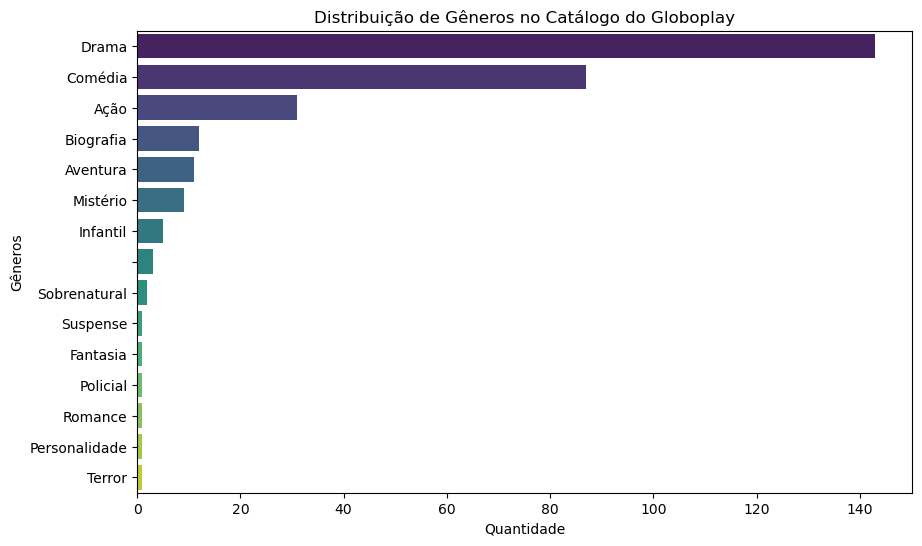

In [21]:
# Quais são os gêneros mais comuns no catálogo do Globoplay?import seaborn as sns

# Ordenar os gêneros por frequência
generos_ordenados = df_definitivo['generos'].value_counts().index

# Criar o gráfico de barras ordenado
plt.figure(figsize=(10, 6))
sns.countplot(y=df_definitivo['generos'], order=generos_ordenados, palette='viridis')
plt.title('Distribuição de Gêneros no Catálogo do Globoplay')
plt.xlabel('Quantidade')
plt.ylabel('Gêneros')
plt.show()


#### **Hipótese: Foco no público adolescente?**
O gênero Drama é frequentemente associado a histórias emocionais e complexas que ressoam bem com adolescentes e jovens adultos. No entanto, para confirmar que este é o público-alvo, seria necessário cruzar esses dados com informações sobre a classificação etária ou dados demográficos da audiência.

##### **Outras conclusões possíveis:**
**Diversidade de Público**:

Como os gêneros Comédia e Ação também aparecem com frequência, o catálogo busca atingir um público variado, abrangendo pessoas que gostam de histórias leves e humorísticas (comédia) ou narrativas intensas e cheias de adrenalina (ação).

**Preferências Culturais**:

A predominância de Drama pode refletir uma tendência cultural de consumo no Brasil, onde narrativas emocionais (como novelas e séries dramáticas) têm ampla aceitação.

**Possíveis Gêneros Menos Representados**:

Gêneros como Terror e Fantasia estão menos presentes, o que pode indicar que o catálogo prioriza histórias mais realistas ou emocionais, em vez de conteúdos que apelam a nichos específicos.

**Estratégia Comercial**:

O foco em gêneros como Drama e Comédia pode ser uma estratégia para atrair mais assinantes, já que são gêneros populares em geral.

**Evolução do Catálogo**:

Pode ser interessante observar como a distribuição de gêneros mudou ao longo do tempo, especialmente se compararmos a proporção de séries de cada gênero por década.

In [22]:
# Existe alguma correlação entre gêneros específicos e classificações etárias?
# Criar uma tabela cruzada entre gênero e classificação etária
tabela_genero_classificacao = pd.crosstab(df_definitivo['generos'], df_definitivo['classificacao_etaria'])
print(tabela_genero_classificacao)

classificacao_etaria  10  12  14  16  18  Erro  Não encontrada  livre
generos                                                              
                       0   1   1   1   0     0               0      0
Aventura               1   1   2   2   0     0               0      5
Ação                   0   1  11  16   3     0               0      0
Biografia              0   1   9   1   1     0               0      0
Comédia                6  34  30   8   0     1               0      8
Drama                  2  16  45  69   8     0               1      2
Fantasia               0   0   0   1   0     0               0      0
Infantil               0   0   0   0   0     0               0      5
Mistério               0   0   1   7   0     0               0      1
Personalidade          0   0   1   0   0     0               0      0
Policial               0   0   0   1   0     0               0      0
Romance                0   0   0   1   0     0               0      0
Sobrenatural        

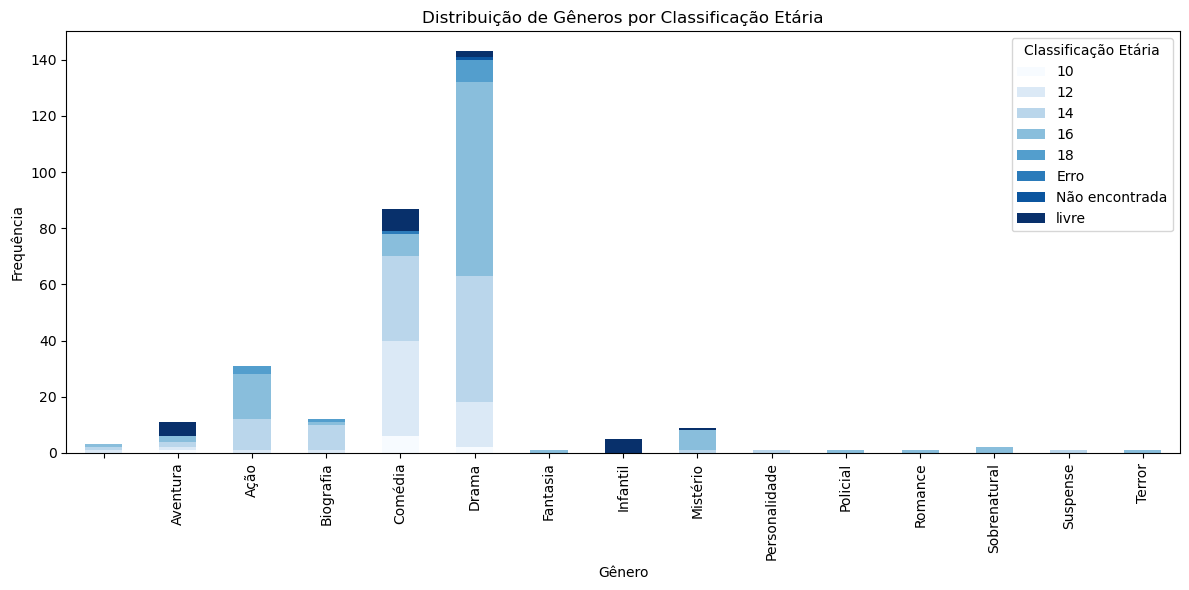

In [23]:
# Plotar gráfico de barras empilhadas
tabela_genero_classificacao.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Blues')
plt.title('Distribuição de Gêneros por Classificação Etária')
plt.ylabel('Frequência')
plt.xlabel('Gênero')
plt.legend(title='Classificação Etária')
plt.tight_layout()
plt.show()


A partir da análise apresentada no gráfico, podemos tirar as seguintes considerações:

### Gêneros e Classificação Etária
1. **Foco em Drama e Comédia para Públicos Mais Velhos:**
   - A predominância de classificações etárias **16+** e **18+** para os gêneros **Drama** e **Comédia** indica que essas categorias são amplamente voltadas para um público mais maduro, que busca narrativas mais complexas e/ou humor mais sofisticado.

2. **Acessibilidade de Aventura e Comédia para Todos os Públicos:**
   - O gênero **Comédia** e, em menor escala, **Aventura** apresentam uma distribuição de classificações etárias mais equilibrada, com uma quantidade considerável de conteúdos **livres** ou **10+**. Isso sugere que esses gêneros são projetados para alcançar uma audiência mais ampla, incluindo crianças e famílias.

### Estratégias de Conteúdo
1. **Diversificação de Público:**
   - **Comédia** e **Aventura** atendem a uma estratégia clara de atingir diferentes faixas etárias, possivelmente para atrair famílias e públicos que preferem conteúdos mais leves e inclusivos.
   - **Drama**, por outro lado, parece focar em uma abordagem mais específica, cativando adolescentes mais velhos e adultos.

2. **Identificação de Gêneros Nichados:**
   - Gêneros como **Terror**, **Mistério** e **Sobrenatural** são menos representados, o que pode indicar que não são o foco principal do Globoplay ou que esses conteúdos são oferecidos com restrições de faixa etária.

### Possíveis Impactos no Catálogo e no Público
1. **Alinhamento com Preferências Culturais:**
   - No Brasil, conteúdos como dramas emocionais e comédias familiares costumam ser populares, especialmente entre adolescentes e adultos, o que pode justificar a predominância desses gêneros no catálogo.

2. **Aventura como Ponto de Expansão:**
   - O gênero **Aventura**, com sua maior flexibilidade etária, pode ser um ponto de crescimento estratégico, pois atende a públicos diversos e oferece potencial de expansão para séries mais inclusivas.

3. **Necessidade de Explorar Mais Gêneros Infantis:**
   - Apesar de **Comédia** e **Aventura** atenderem bem a públicos mais jovens, os gêneros voltados exclusivamente para crianças (como **Infantil**) ainda são limitados no catálogo.

---

Essa análise pode ser complementada com insights de consumo de audiência para verificar quais gêneros realmente atraem mais espectadores e quais possuem potencial de crescimento.

In [24]:
# Qual gênero domina os lançamentos em determinado período (ex.: última década)?
# Criar uma tabela cruzada de gêneros por década
tabela_genero_decada = pd.crosstab(df_definitivo['generos'], df_definitivo['decada'])
print(tabela_genero_decada)

decada         1980s  1990s  2000s  2010s  2020s  Ano não encontrado
generos                                                             
                   0      2      0      0      1                   0
Aventura           0      0      1      4      6                   0
Ação               0      0      0     16     14                   1
Biografia          0      1      0      8      3                   0
Comédia            0      2      9     45     24                   7
Drama              8     13     16     56     50                   0
Fantasia           0      0      0      0      1                   0
Infantil           0      0      3      1      1                   0
Mistério           0      0      0      3      6                   0
Personalidade      0      0      0      0      1                   0
Policial           0      0      0      1      0                   0
Romance            0      0      0      1      0                   0
Sobrenatural       0      0      0

In [25]:
# Encontrar o gênero mais frequente em cada década
genero_dominante_por_decada = tabela_genero_decada.idxmax()
print(genero_dominante_por_decada)

decada
1980s                   Drama
1990s                   Drama
2000s                   Drama
2010s                   Drama
2020s                   Drama
Ano não encontrado    Comédia
dtype: object


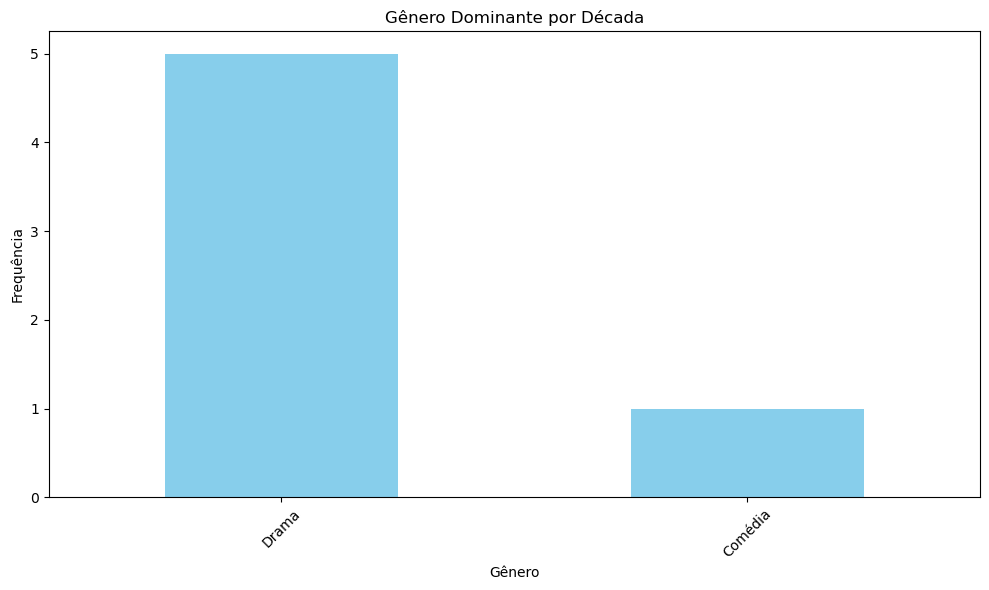

In [26]:
# Plotar os resultados
tabela_genero_decada.idxmax().value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Gênero Dominante por Década')
plt.ylabel('Frequência')
plt.xlabel('Gênero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Após observar que o gênero Drama predomina em todas as décadas no catálogo analisado, levanta-se a hipótese de que uma das razões para esse domínio possa estar relacionada à presença de subgêneros. Muitas séries classificadas como Drama possuem elementos de outros gêneros em suas narrativas, como Aventura, Terror ou Mistério, o que sugere uma estratégia de diversificação de conteúdo. Essa combinação permite que o Drama atue como o gênero central, enquanto os subgêneros agregam camadas de complexidade e ampliam o apelo dessas produções para diferentes públicos e sim, essa combinação de subgêneros como **Drama e Aventura** ou **Drama e Terror** pode indicar uma **tendência estratégica** na criação e curadoria de conteúdos. Essa abordagem reflete o desejo de oferecer histórias que mesclem elementos emocionais profundos (característicos do drama) com componentes de outros gêneros que ampliem o apelo do conteúdo para diferentes públicos.

### Por que isso pode ser uma tendência?
1. **Atração de um Público Diversificado:**  
   - Combinar drama com outros gêneros permite atingir públicos variados, como aqueles que gostam de tramas emocionais, mas que também buscam aventura, mistério ou até terror.  

2. **Riqueza de Narrativa:**  
   - Subgêneros adicionam camadas de complexidade às histórias, tornando-as mais ricas e multifacetadas. Isso mantém o público engajado por mais tempo.

3. **Tendência Global em Séries e Filmes:**  
   - É comum ver produções modernas misturando gêneros para criar algo mais inovador e menos previsível, como por exemplo:
     - **Drama + Aventura**: Para contar histórias de superação emocional em contextos épicos ou exploratórios.
     - **Drama + Terror**: Para explorar medos ou traumas humanos de maneira psicológica e envolvente.

4. **Apoio ao Streaming:**  
   - No streaming, a diversidade de combinações ajuda a aumentar as chances de que uma série ou filme se conecte com mais assinantes, o que é crucial para retenção de público.

### Possíveis Conclusões
- **Flexibilidade e Versatilidade:** O drama é uma base sólida para narrativas, pois se conecta com emoções humanas universais. Quando combinado com outros gêneros, ele se adapta a diferentes preferências culturais e etárias.
  
- **Foco em Gêneros Secundários em Curadoria:** A predominância do drama como um "gênero principal" pode estar associada à estratégia do Globoplay de garantir que o conteúdo seja mais emocionalmente impactante, enquanto subgêneros adicionam um diferencial de interesse.

- **Tendência de Produção Global:** Essa mistura de gêneros pode ser influenciada por grandes produções globais, que frequentemente combinam drama com ação, aventura ou mistério para maximizar seu apelo.

### Análise Futura
Podemos investigar:
1. Quantos desses dramas possuem subgêneros e quais são as combinações mais comuns.
2. A relação dessas combinações com a audiência ou engajamento (se você tiver acesso a esses dados).
3. Se essa estratégia é igualmente presente em outros serviços de streaming, comparando com a Netflix ou Amazon Prime, por exemplo. 

Esses dados podem oferecer insights sobre tendências de produção e preferências do público no contexto de plataformas digitais.

### Classificação Etária

In [27]:
# Qual é a distribuição das classificações etárias no catálogo?
# Filtrar classificações etárias válidas
df_validas = df_definitivo[~df_definitivo['classificacao_etaria'].isin(['Não encontrada', 'Erro'])]

In [28]:
# Contar a frequência de cada classificação etária
distribuicao_classificacao = df_validas['classificacao_etaria'].value_counts()
print(distribuicao_classificacao)

classificacao_etaria
16       110
14       101
12        54
livre     21
18        12
10         9
Name: count, dtype: int64


In [29]:
# Calcular os percentuais de cada classificação etária
distribuicao_percentual = df_validas['classificacao_etaria'].value_counts(normalize=True) * 100
print(distribuicao_percentual)

classificacao_etaria
16       35.830619
14       32.899023
12       17.589577
livre     6.840391
18        3.908795
10        2.931596
Name: proportion, dtype: float64


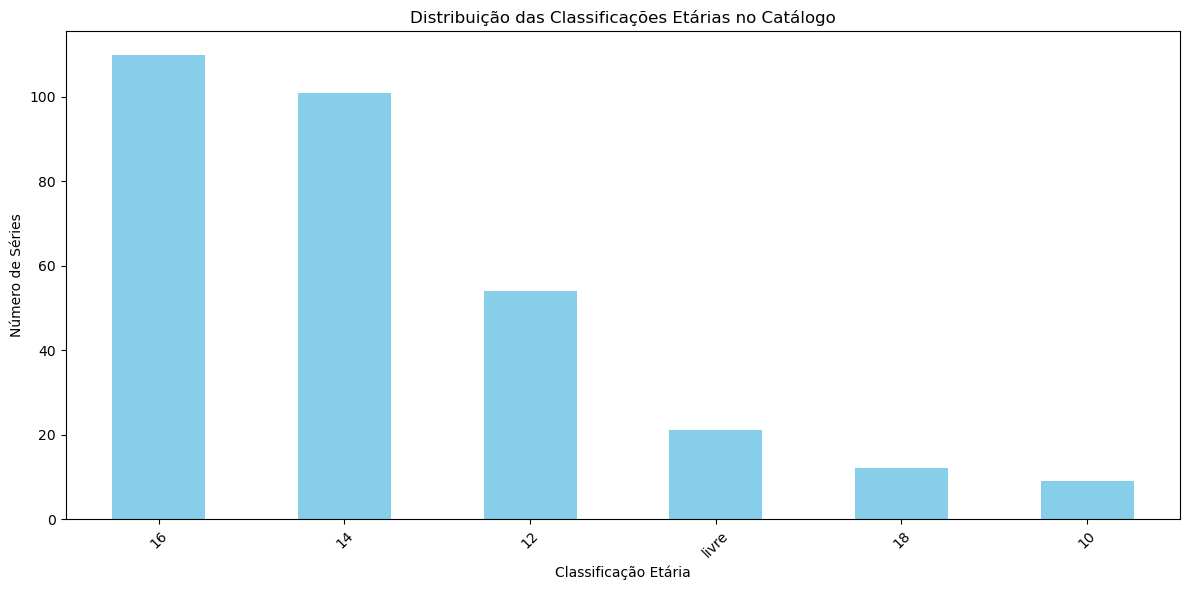

In [30]:
# Gráfico de barras para distribuições
distribuicao_classificacao.plot(kind='bar', color='skyblue', figsize=(12, 6))
plt.title('Distribuição das Classificações Etárias no Catálogo')
plt.xlabel('Classificação Etária')
plt.ylabel('Número de Séries')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Há maior parte do conteudo das series tem classificaçao etaria de 16 e 14 anos, o foco disso deve ser porque os adolescentes tem mais tempo livre para gastar com series

isso pode ser uma estrategia global, pois adolescentes além de terem mais tempo livre, ainda podem influenciar outras pessoas a consumir tal conteudo

In [31]:
# Existe algum gênero predominante em uma faixa etária específica (ex.: séries de comédia para 12 anos)?
# Essa pergunta é parecida com a de dominância por década, então o processo para responde-la vai ser o mesmo
genero_dominante_por_faixa = pd.crosstab(df_definitivo.generos, df_definitivo.classificacao_etaria)
print(genero_dominante_por_faixa)

classificacao_etaria  10  12  14  16  18  Erro  Não encontrada  livre
generos                                                              
                       0   1   1   1   0     0               0      0
Aventura               1   1   2   2   0     0               0      5
Ação                   0   1  11  16   3     0               0      0
Biografia              0   1   9   1   1     0               0      0
Comédia                6  34  30   8   0     1               0      8
Drama                  2  16  45  69   8     0               1      2
Fantasia               0   0   0   1   0     0               0      0
Infantil               0   0   0   0   0     0               0      5
Mistério               0   0   1   7   0     0               0      1
Personalidade          0   0   1   0   0     0               0      0
Policial               0   0   0   1   0     0               0      0
Romance                0   0   0   1   0     0               0      0
Sobrenatural        

In [32]:
# Encontrar  gênero mais frequente por faixa etária
tabela_genero_dominante_por_faixa = genero_dominante_por_faixa.idxmax()
print(tabela_genero_dominante_por_faixa) 

classificacao_etaria
10                Comédia
12                Comédia
14                  Drama
16                  Drama
18                  Drama
Erro              Comédia
Não encontrada      Drama
livre             Comédia
dtype: object


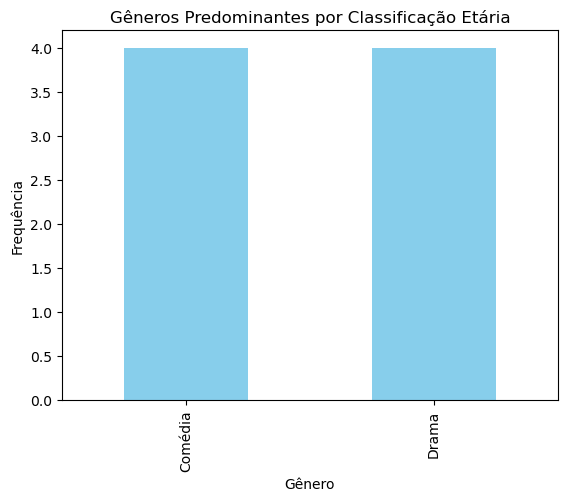

In [33]:
# Criar um gráfico de barras
tabela_genero_dominante_por_faixa.value_counts().plot(kind='bar', color='skyblue')
plt.title('Gêneros Predominantes por Classificação Etária')
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.show()


1. **O que pode justificar o fato de séries de comédia terem maior representatividade no público infantil (12 anos ou menos), enquanto séries de drama tendem a se concentrar no público adolescente?**  

2. **O público adolescente é o principal foco das séries de drama devido à sua maior vivência e capacidade de assimilar narrativas mais complexas e emocionalmente densas?**  

Essa diferença pode ser explicada pelas características narrativas e temáticas que cada gênero aborda. Séries de comédia geralmente utilizam narrativas simples, personagens cativantes e humor acessível, elementos que são mais eficazes para envolver crianças. Essas produções costumam ser mais leves e diretas, o que facilita o engajamento desse público.

Já o foco do gênero Drama no público adolescente pode estar relacionado ao estágio de desenvolvimento dessa faixa etária. Adolescentes possuem maior capacidade de abstração e interpretação de tramas complexas, além de começarem a se interessar por questões emocionais e sociais mais profundas. O drama frequentemente explora conflitos pessoais, relacionamentos e temas relevantes, permitindo que o público jovem se conecte com as histórias e encontre nelas elementos que refletem suas próprias experiências e desafios.

Essa divisão de foco pode ser estratégica, pois alinha as características narrativas de cada gênero às necessidades e preferências emocionais de seus públicos-alvo, maximizando o engajamento e a identificação.

### Análise Temporal

<Axes: xlabel='decada', ylabel='count'>

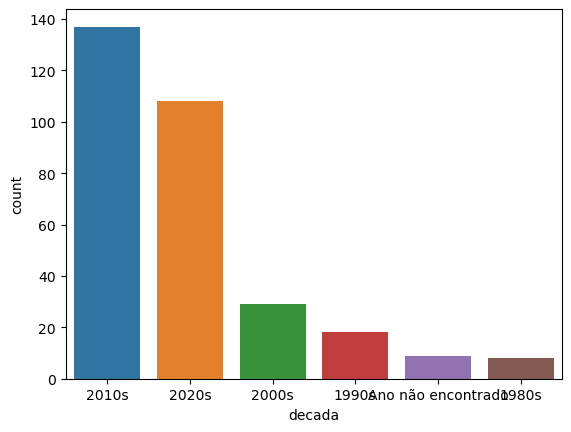

In [34]:
# Em qual década há o maior número de lançamentos de séries?
sns.countplot(x = df_definitivo.decada)


Observa-se que a maioria das séries no catálogo do Globoplay pertence às décadas de 2010 e 2020. Isso pode ser uma estratégia para manter o catálogo atualizado, visando atrair um público que prefere tramas recentes e com temas contemporâneos que facilitem a identificação. Por outro lado, a baixa presença de séries dos anos 1980 pode estar relacionada à menor demanda por produções dessa época, devido a fatores como qualidade técnica inferior, menor relevância cultural para gerações mais jovens ou dificuldade de acesso e licenciamento de obras mais antigas.

### Comparação entre Gêneros e Classificação Etária

In [35]:
# Gêneros de drama possuem classificações etárias mais altas do que comédia?
# Primeiro vamos filtrar as colunas que usaremos para responder essa pergunta
df_class_genero = df_definitivo.iloc[:, [2, 3]]
print(df_class_genero)

    classificacao_etaria    generos
7                     12    Comédia
8                     16      Drama
9                     14    Comédia
10                    18       Ação
11                    12    Comédia
..                   ...        ...
311                   10    Comédia
312                   16      Drama
313                   14      Drama
314                   14  Biografia
315       Não encontrada      Drama

[309 rows x 2 columns]


In [36]:
# Agora vamos filtrar os dados onde só pegaremos os gêneros Drama e Comédia
filtrar_drama_comedia = df_class_genero[(df_class_genero['generos'] == 'Drama') | (df_class_genero['generos'] == 'Comédia')]
filtrar_drama_comedia.head()

,classificacao_etaria,generos
7,12,Comédia
8,16,Drama
9,14,Comédia
11,12,Comédia
12,18,Drama


In [37]:
filtrar_drama_comedia.shape

(230, 2)

<Axes: xlabel='classificacao_etaria', ylabel='count'>

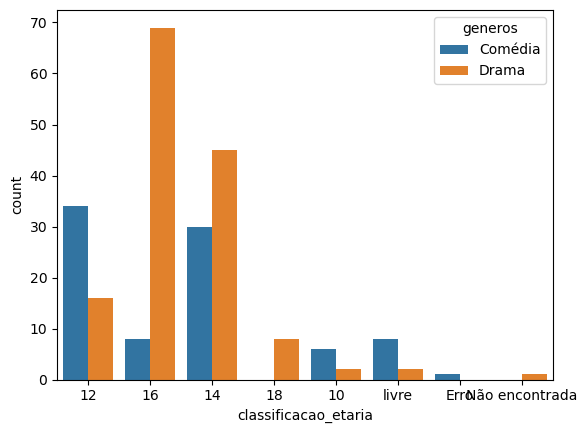

In [38]:
sns.countplot(
    data=filtrar_drama_comedia,
    x="classificacao_etaria", hue="generos")

Nota-se que séries do gênero drama frequentemente possuem classificação etária mais alta, devido à sua complexidade narrativa, o que as torna mais atraentes para o público adolescente e adulto. Já as séries de comédia, com tramas mais simples, tendem a ser direcionadas ao público mais jovem. Porém, o que justificaria a falta de frequência de séries de comédia voltadas ao público adulto? Isso poderia estar relacionado a uma estratégia de alcance mais amplo, onde a comédia busca atrair diferentes faixas etárias, enquanto as séries de drama são geralmente mais segmentadas, com um público-alvo claramente definido. Essa diferença pode refletir decisões estratégicas no desenvolvimento de conteúdo e posicionamento no mercado.

### Análise do Catálogo

In [40]:
# Qual é a proporção de séries clássicas (lançadas antes dos anos 2000) no catálogo?

# Garantir que a modificação seja feita diretamente no DataFrame principal
df_definitivo.loc[:, 'ano_lancamento'] = pd.to_numeric(df_definitivo['ano_lancamento'], errors='coerce')

# Criar a coluna 'classico' indicando se a série é clássica
df_definitivo.loc[:, 'classico'] = df_definitivo['ano_lancamento'].apply(lambda x: x < 2000)

# Exibir as primeiras linhas para verificar
print(df_definitivo[['ano_lancamento', 'classico']].head(3))


  ano_lancamento  classico
7         2011.0     False
8         2020.0     False
9         2024.0     False


C:\Users\pc\AppData\Local\Temp\ipykernel_9024\2110509036.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_definitivo.loc[:, 'classico'] = df_definitivo['ano_lancamento'].apply(lambda x: x < 2000)


In [41]:
# Calcular a proporção de séries clássicas
proporcao_classicas = df_definitivo['classico'].mean() * 100

print(f"A proporção de séries clássicas no catálogo é de {proporcao_classicas:.2f}%")


A proporção de séries clássicas no catálogo é de 8.41%


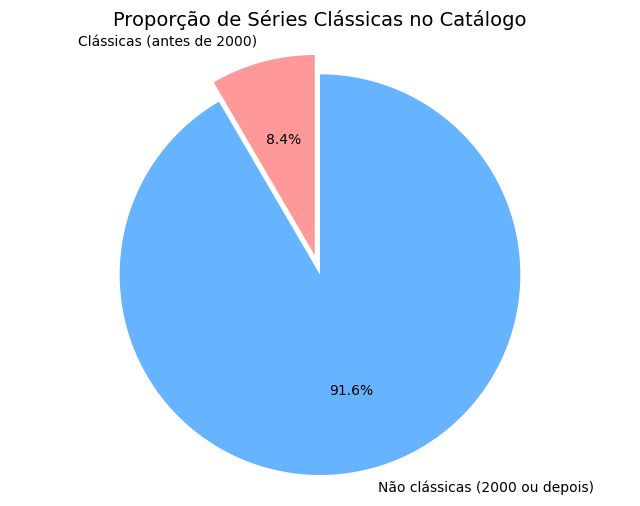

In [42]:
# Dados para o gráfico
total_series = len(df_definitivo)
classicas_count = df_definitivo['classico'].sum()
nao_classicas_count = total_series - classicas_count

# Criar os dados para o gráfico de pizza
labels = ['Clássicas (antes de 2000)', 'Não clássicas (2000 ou depois)']
sizes = [classicas_count, nao_classicas_count]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # Destaque na fatia das clássicas

# Criar o gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Proporção de Séries Clássicas no Catálogo', fontsize=14)
plt.axis('equal')  # Assegura que o gráfico é desenhado como um círculo
plt.show()


Apenas 8,4% das séries do Globoplay são de antes dos anos 2000. Essa baixa representatividade pode estar relacionada a dificuldades na obtenção de licenças para séries mais antigas, além das limitações técnicas dessas produções, que podem não atender aos padrões de qualidade exigidos pelo público atual. Outro fator importante é a estratégia de manter o catálogo atrativo para o público adolescente, que constitui uma parcela significativa dos consumidores. Séries mais antigas, por retratarem contextos e épocas distantes, podem dificultar a identificação desse público, resultando em menor engajamento.

In [43]:
# Existe alguma relação entre o ano de lançamento e a classificação etária?
# Agrupamento e Contagem
relacao_ano_classificacao = df_definitivo.groupby(['ano_lancamento', 'classificacao_etaria']).size().reset_index(name='quantidade')


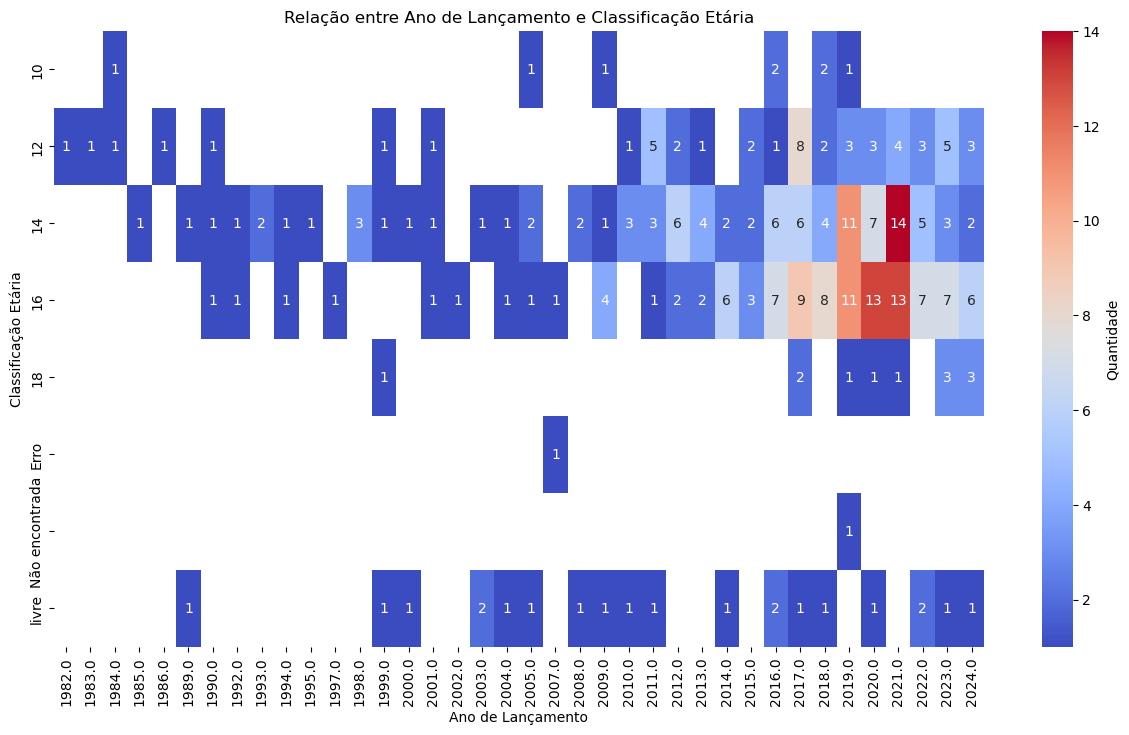

In [44]:
# Agrupando os dados
relacao_ano_classificacao = df_definitivo.groupby(['ano_lancamento', 'classificacao_etaria']).size().reset_index(name='quantidade')

# Plotando um heatmap
pivot_table = relacao_ano_classificacao.pivot(index='classificacao_etaria', columns='ano_lancamento', values='quantidade')
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt='.0f', cbar_kws={'label': 'Quantidade'})
plt.title('Relação entre Ano de Lançamento e Classificação Etária')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Classificação Etária')
plt.show()


O Globoplay tem priorizado séries recentes (de 2019 a 2021) e com foco em faixas etárias de 14 e 16 anos. Isso pode ser explicado por uma estratégia de manter o catálogo atualizado e direcionado a um público adolescente, que busca conteúdos mais atuais e conectados com suas realidades.  

A escolha desse público-alvo também reflete uma aposta no consumo contínuo, já que os adolescentes podem se tornar consumidores fiéis à medida que amadurecem. Além disso, séries nessa faixa etária geralmente têm maior flexibilidade narrativa para engajar tanto jovens quanto jovens adultos, ampliando o alcance do conteúdo.

### Insights para Estratégias de Mercado

In [45]:
# Em quais períodos houve mais lançamentos de séries voltadas para o público adulto?
# Filtrando as linhas onde a classificação etária é "18"
publico_adulto = df_definitivo[(df_definitivo['classificacao_etaria'] == '18')]

# Exibindo as primeiras linhas do DataFrame filtrado
print(publico_adulto.head())


                                                 link ano_lancamento  \
10  https://globoplay.globo.com/arcanjo-renegado/t...         2020.0   
12  https://globoplay.globo.com/law-order-svu/t/Qm...         1999.0   
42  https://globoplay.globo.com/the-handmaids-tale...         2017.0   
53  https://globoplay.globo.com/o-jogo-que-mudou-a...         2024.0   
65  https://globoplay.globo.com/o-tatuador-de-ausc...         2024.0   

   classificacao_etaria generos decada  classico  
10                   18    Ação  2020s     False  
12                   18   Drama  1990s      True  
42                   18   Drama  2010s     False  
53                   18    Ação  2020s     False  
65                   18   Drama  2020s     False  


In [46]:
print(f"Total de séries com classificação etária '18': {len(publico_adulto)}")

Total de séries com classificação etária '18': 12


<Axes: xlabel='decada', ylabel='count'>

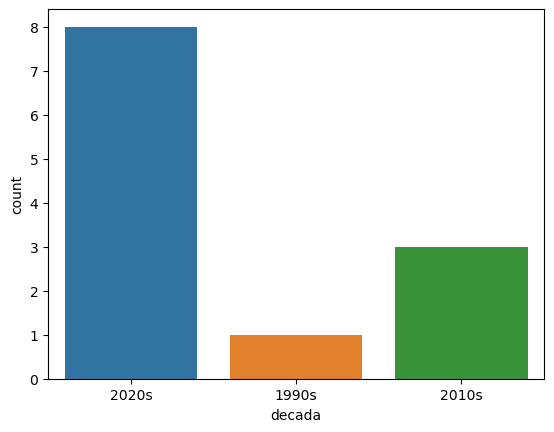

In [47]:
sns.countplot(x = publico_adulto.decada)

A década de 2020 apresenta o maior número de séries voltadas para o público +18 no Globoplay. Essa tendência pode ser explicada por uma estratégia do serviço de streaming em acompanhar o envelhecimento de seu público adolescente, reconhecendo que muitos deles agora são jovens adultos. Essa mudança reflete uma possível adaptação do catálogo para atender a novas demandas desse segmento de consumidores?


Sim, esse é um ponto relevante a ser analisado. Um analista de dados pode reestruturar essa questão de forma mais objetiva:  

O aumento do foco em séries para o público +18 na década de 2020 pode representar um risco para o consumo geral do catálogo, considerando que o envelhecimento do público-alvo original pode afastar potenciais novos assinantes mais jovens? Quais estratégias poderiam ser adotadas para equilibrar o conteúdo e atrair tanto jovens quanto adultos?

Essa questão também abre espaço para análises complementares, como a avaliação do comportamento de consumo por faixa etária e o impacto da diversificação do catálogo na retenção de assinantes.

In [48]:
# Qual gênero poderia ser mais explorado, considerando as lacunas no catálogo atual?

# Contagem de frequência dos gêneros
genero_frequencia = df_definitivo['generos'].explode().value_counts()
print(genero_frequencia)


generos
Drama            143
Comédia           87
Ação              31
Biografia         12
Aventura          11
Mistério           9
Infantil           5
                   3
Sobrenatural       2
Suspense           1
Fantasia           1
Policial           1
Romance            1
Personalidade      1
Terror             1
Name: count, dtype: int64


In [49]:
limite = 0.05 * len(df_definitivo)  # 5% do total
generos_sub_representados = genero_frequencia[genero_frequencia < limite]
print(generos_sub_representados)

generos
Biografia        12
Aventura         11
Mistério          9
Infantil          5
                  3
Sobrenatural      2
Suspense          1
Fantasia          1
Policial          1
Romance           1
Personalidade     1
Terror            1
Name: count, dtype: int64


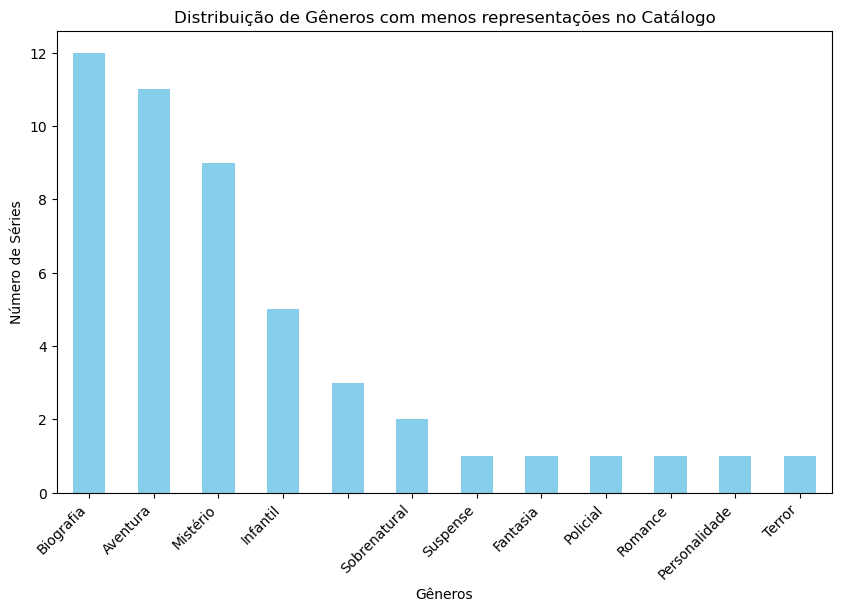

In [50]:
# Criando o plot
generos_sub_representados.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Distribuição de Gêneros com menos representações no Catálogo')
plt.xlabel('Gêneros')
plt.ylabel('Número de Séries')
plt.xticks(rotation=45, ha='right')
plt.show()

Sua observação sobre a baixa representatividade de certos gêneros no catálogo do Globoplay é interessante e levanta uma questão relevante sobre a estratégia de curadoria da plataforma. É possível que a predominância de gêneros mais "realistas" esteja alinhada com o perfil de conteúdo historicamente associado à Globo, que frequentemente busca criar histórias próximas à realidade para ressoar com o público brasileiro.

Aqui estão algumas considerações sobre essa estratégia:

1. **Foco no Público-Alvo Tradicional**  
   A Globo tem uma longa tradição de produzir novelas e séries com tramas que refletem aspectos do cotidiano, dramas familiares e conflitos sociais, o que pode explicar a preferência por gêneros mais "realistas" e menos fantásticos. Essa abordagem ajuda a manter uma conexão cultural com o público.

2. **Restrição no Mercado de Produção Local**  
   Gêneros como biografia, aventura e mistério demandam roteiros e produções específicas que podem ser menos frequentes no mercado brasileiro. Além disso, gêneros como fantasia e sobrenatural requerem orçamentos altos e tecnologia avançada, o que pode limitar sua presença no catálogo.

3. **Estratégia de Diferenciação**  
   Enquanto plataformas internacionais como Netflix e Amazon Prime investem pesadamente em gêneros fantásticos e sobrenaturais, o Globoplay pode estar deliberadamente focando em um diferencial competitivo: oferecer um catálogo mais enraizado na realidade brasileira e nas histórias locais.

4. **Risco Comercial**  
   Gêneros como terror, fantasia e policial têm nichos de público mais restritos e podem apresentar maior risco comercial. Investir nesses gêneros sem uma base de fãs sólida pode não gerar o retorno esperado.

5. **Adaptação Gradual**  
   É possível que a Globo esteja testando gradualmente a aceitação de gêneros menos convencionais no catálogo, como os títulos únicos em fantasia, terror e policial, antes de expandir o investimento nesses segmentos.

**Perguntas para análise futura:**  
- O Globoplay planeja aumentar a diversidade de gêneros para atrair novos públicos?  
- Como o público brasileiro responde a produções de gêneros menos realistas disponíveis na plataforma?  
- Quais seriam os desafios e oportunidades para a Globo ao investir em produções de fantasia, terror e aventura?  

Essas perguntas podem ajudar a entender melhor a estratégia e os impactos de ampliar o leque de gêneros no catálogo.

In [51]:
# Existe algum gênero pouco representado em séries com classificação "Livre"?
# Filtrando todo o conteúdo onde a classificação é livre

series_livres = df_definitivo[df_definitivo['classificacao_etaria'] == 'livre']

In [52]:
# Contar a frequência
frequencia_generos_livres = series_livres['generos'].explode().value_counts()
print(frequencia_generos_livres)

generos
Comédia     8
Infantil    5
Aventura    5
Drama       2
Mistério    1
Name: count, dtype: int64


In [53]:
print(f"O total de séries com classificação etária 'livre': {len(series_livres)}")

O total de séries com classificação etária 'livre': 21


In [54]:
limite_representacao = 5  # Exemplo: menos de 5 séries
generos_pouco_representados = frequencia_generos_livres[frequencia_generos_livres < limite_representacao]
print(generos_pouco_representados)

generos
Drama       2
Mistério    1
Name: count, dtype: int64


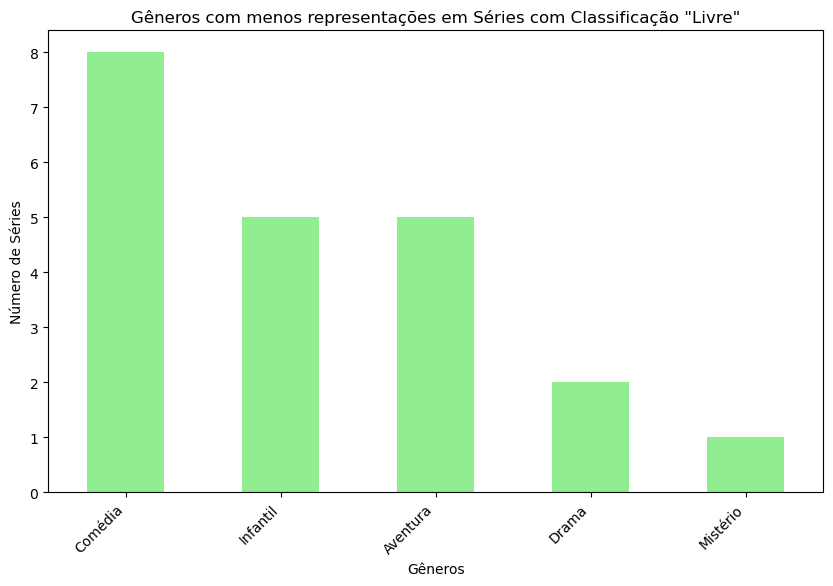

In [55]:
# Plotando o gráfico
frequencia_generos_livres.plot(kind='bar', figsize=(10, 6), color='lightgreen')
plt.title('Gêneros com menos representações em Séries com Classificação "Livre"')
plt.xlabel('Gêneros')
plt.ylabel('Número de Séries')
plt.xticks(rotation=45, ha='right')
plt.show()

Esses dados parecem reforçar a ideia de que o Globoplay adota uma estratégia que prioriza tramas mais realistas e relacionadas ao cotidiano, mesmo para conteúdos classificados como "livre". Aqui está uma análise mais aprofundada dessa observação:

### Conexão com o Público Brasileiro  
O público brasileiro tem uma forte conexão com histórias que refletem sua própria realidade e cultura. Ao restringir os gêneros classificados como "livre" a opções mais acessíveis e identificáveis, como **comédia, infantil e aventura**, a plataforma mantém sua aderência a temas que são amplamente aceitos e compreendidos.

### Estratégia de Segmentação  
Gêneros como **drama e mistério** aparecem menos nessa classificação, provavelmente devido à sua complexidade narrativa, que pode exigir uma compreensão mais madura. Esse tipo de segmentação parece intencional para garantir que conteúdos voltados para um público amplo sejam leves, fáceis de assimilar e com menor carga emocional.

### Realismo e Familiaridade  
A baixa representação de gêneros como mistério, mesmo na classificação livre, pode ser reflexo da preferência da plataforma por narrativas que dialoguem mais diretamente com o cotidiano. Isso evita afastar o público infantil e familiar com histórias excessivamente abstratas ou que demandem uma interpretação mais densa.

### Outras Considerações Estratégicas:  
1. **Reputação e Expectativas**  
   O Globoplay, como parte da Globo, tem um legado de produzir conteúdos que refletem o "espelho da sociedade". Isso pode justificar a escolha de manter as produções livres próximas da realidade, evitando o risco de alienar o público-alvo.

2. **Demanda de Produção**  
   Gêneros mais fantásticos ou complexos, como ficção científica ou thrillers de mistério, demandam recursos elevados e muitas vezes não se alinham ao foco em produções locais, especialmente para audiências mais jovens.

3. **Educação e Valores**  
   Os conteúdos "livres" muitas vezes também têm um papel educativo ou formativo. Gêneros como comédia e infantil podem ser usados para reforçar valores culturais e sociais, o que é mais difícil de alcançar em gêneros como mistério ou drama.

### Perguntas para Investigar  
- Seria interessante diversificar os gêneros na classificação livre para ampliar o público?  
- Como o público infantil e familiar brasileiro responde a gêneros fora dos tradicionais?  
- A ausência de fantasia ou ficção científica na classificação livre é uma lacuna ou uma escolha estratégica baseada no público atual?  

Essas reflexões ajudam a consolidar a ideia de que o Globoplay escolhe deliberadamente os gêneros para atender às expectativas e manter a conexão emocional com o público brasileiro.

### Considerações e Conclusões Finais  

1. **Drama como Gênero Dominante**  
   O gênero **drama** é amplamente representado, possivelmente por ser mais versátil e capaz de abordar temas realistas e emocionais, o que ressoa com o público adolescente e adulto. Esse foco reflete a busca do Globoplay por conteúdos que criem identificação e engajamento emocional.

2. **Estratégia de Atualização do Catálogo**  
   A predominância de séries das décadas de 2010 e 2020 sugere um esforço para manter o catálogo atualizado, focando em produções contemporâneas que atraem um público conectado com narrativas modernas e valores atuais.

3. **Classificação Etária Alinhada ao Conteúdo**  
   Séries de drama tendem a ter classificações etárias mais altas, refletindo sua complexidade narrativa e temas densos. Em contrapartida, gêneros como comédia e infantil possuem mais representatividade nas classificações livres, o que evidencia uma segmentação clara do público.

4. **Baixa Representação de Certos Gêneros**  
   Gêneros como terror, fantasia e ficção científica têm pouca representação, indicando uma escolha estratégica por narrativas mais realistas e alinhadas ao cotidiano, com menor dependência de efeitos especiais ou produções de alto custo.

5. **Foco no Público Adolescente e Jovem Adulto**  
   A análise sugere que o Globoplay acompanha a evolução de seu público-alvo, investindo em conteúdos que transitam entre as classificações de adolescentes para jovens adultos (+18), mantendo a fidelidade desse grupo à medida que envelhecem.

---

### Próximas Perguntas Interessantes  

Com acesso a métricas detalhadas do Globoplay, algumas perguntas poderiam ser exploradas para enriquecer a análise:

#### Sobre o Consumo do Público:
- **Quais são os gêneros com maior tempo médio de visualização?**  
- **Há diferenças significativas na audiência de séries entre regiões do Brasil?**  
- **O público consome mais séries contemporâneas ou clássicas (antes dos anos 2000)?**

#### Sobre a Eficácia do Catálogo:  
- **Qual é a taxa de conclusão por série e como isso varia por gênero?**  
- **Quais são os gêneros que mais atraem novos assinantes?**  
- **Séries com subgêneros (e.g., drama + aventura) têm melhor desempenho do que séries de gênero único?**

#### Sobre a Estratégia de Licenciamento:  
- **A inclusão de mais séries clássicas impactaria positivamente no engajamento de públicos específicos, como adultos nostálgicos?**  
- **Qual é o retorno sobre o investimento (ROI) para séries menos representadas, como terror ou suspense?**  

#### Sobre o Público Infantil:  
- **Séries infantis têm maior taxa de visualização em horários específicos do dia?**  
- **Como o público infantil e seus responsáveis respondem à inclusão de valores educacionais nas séries?**

#### Tendências Futuras:  
- **Há demanda crescente por gêneros como ficção científica e fantasia, apesar de sua baixa representação atual?**  
- **Como as produções nacionais se comparam às internacionais em termos de engajamento?**

Essas questões poderiam orientar decisões estratégicas, como diversificação do catálogo, criação de novos conteúdos originais, ou melhorias na segmentação de público.